# 01 — Data Preprocessing

**Goal:** load the medical dataset, explore it, handle missing values, encode labels,
standardize features, split into train/test, and save the processed arrays so that
every downstream notebook (baseline classifier + GA/PSO/GWO/WOA feature selection)
works from an identical, frozen dataset.

This notebook is deliberately self-contained — it does not depend on any other
notebook having run first.

In [1]:
# If running on Kaggle, uncomment to install any missing packages
# !pip install -q scikit-learn pandas numpy

import sys
sys.path.append("..")  # so we can import the shared utils/ package

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils.preprocessing import (
    load_dataset,
    explore_dataset,
    handle_missing_values,
    encode_labels,
    preprocess_and_split,
    save_processed_data,
)

## 1. Load dataset

Default: the Wisconsin Breast Cancer dataset (binary classification, 30 numeric features). Swap `source="csv"` to point at any other medical dataset added to your Kaggle notebook's input directory.

In [2]:
X, y = load_dataset(source="breast_cancer")
print("Features shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Features shape: (569, 30)
Target shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Explore dataset

In [3]:
explore_dataset(X, y)

Shape: (569, 30)

Class balance:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64

Missing values per column:
No missing values.

Describe:
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
t

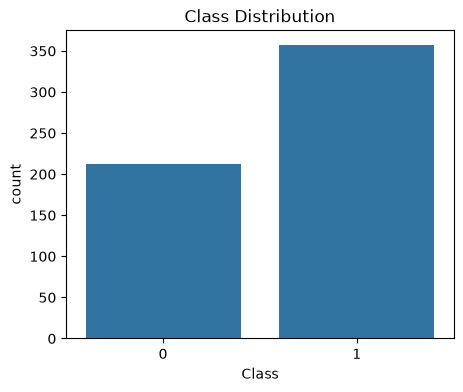

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.show()

## 3. Handle missing values

The breast cancer dataset has no missing values, but this step is included so the pipeline generalizes to any real-world medical dataset you swap in.

In [6]:
X_clean = handle_missing_values(X, strategy="median")
print("Missing values remaining:", X_clean.isnull().sum().sum())

Missing values remaining: 0


## 4. Encode labels

In [7]:
y_encoded, label_encoder = encode_labels(y)
print("Classes:", label_encoder.classes_)
print("Encoded label sample:", y_encoded[:10])

Classes: [0 1]
Encoded label sample: [0 0 0 0 0 0 0 0 0 0]


## 5. Train/test split

In [8]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_clean.values,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## 6. Normalize / standardize features

We fit the scaler on the training set only, then apply it to the test set, to avoid data leakage.

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("X_train mean ~0, std ~1:")
print(X_train.mean(axis=0)[:5].round(3))
print(X_train.std(axis=0)[:5].round(3))

X_train mean ~0, std ~1:
[-0.  0. -0.  0.  0.]
[1. 1. 1. 1. 1.]


## 7. Save processed datasets

Saved to `../datasets/` so every subsequent notebook (`02_Baseline_Classifier`,
`03_GA`, `04_PSO`, `05_GWO`, `06_WOA`) can load the *exact same* split.

In [10]:
feature_names = list(X_clean.columns)

save_processed_data(
    X_train, X_test, y_train, y_test,
    feature_names=feature_names,
    out_dir="../datasets",
)

Saved processed data to ../datasets


## Summary

| Item | Value |
|---|---|
| Total features | `X_train.shape[1]` |
| Train samples | `X_train.shape[0]` |
| Test samples | `X_test.shape[0]` |

Processed data is saved and ready for `02_Baseline_Classifier.ipynb`.